# Classificação Estelar (Galáxias, Quasares e Estrelas) com PyTorch
**Base de Dados:** Stellar Classification Dataset - SDSS17

Este projeto visa construir e otimizar uma Rede Neural Artificial utilizando PyTorch para classificar objetos celestes com base em suas características espectrais. Durante o projeto, foi explorado os fundamentos de Deep Learning, incluindo a arquitetura da rede (largura e profundidade), o impacto da taxa de aprendizado (learning rate) e suas respectivas épocas, além da aplicação de técnicas de regularização e otimização avançada.

## 0. Importação de Bibliotecas e Configuração do Dispositivo

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Configurando o dispositivo (Usa GPU se disponível, senão CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando o dispositivo: {device}')

Usando o dispositivo: cpu


## 1. Pré-processamento dos Dados
De acordo com os conceitos de *Hands-on Machine Learning*, redes neurais são muito sensíveis à escala dos dados. Por isso, precisamos:
1. Carregar o banco de dados.
2. Remover colunas de identificação (IDs) que não ajudam na generalização e podem confundir o modelo.
3. Transformar os rótulos de texto (GALAXY, QSO, STAR) em números (0, 1, 2).
4. Escalar os atributos (StandardScaler) para que o Gradiente Descendente convirja mais rápido.

In [4]:

caminho_banco_dados = '../data/star_classification.csv'
df = pd.read_csv(caminho_banco_dados)

# Removendo colunas que são apenas identificadores e não características físicas
colunas_para_remover = ['obj_ID', 'run', 'rerun', 'camcol', 'field', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df = df.drop(columns=colunas_para_remover, errors='ignore')

# Separando as *features* (X) do *target* (y)
X = df.drop('class', axis=1).values

# Codificando os rótulos (GALAXY=0, QSO=1, STAR=2)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['class'])
print("Classes mapeadas:", label_encoder.classes_)

# Dividindo em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Padronizando os dados (Média 0, Desvio Padrão 1) - Essencial para Redes Neurais
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertendo arrays do Numpy para Tensores do PyTorch (Capítulo 3 de Deep Learning with PyTorch)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Criando DataLoaders para treinar em lotes (mini-batches)
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Capturando o número de features de entrada
input_size = X_train.shape[1]
num_classes = 3

Classes mapeadas: ['GALAXY' 'QSO' 'STAR']


## Atividade A: Criando a Rede Neural Base no PyTorch
Como visto no curso *Neural Networks and Deep Learning*, será construida uma arquitetura *Feedforward* padrão. Usaremos a função de ativação **ReLU** nas camadas ocultas (para lidar com o problema do gradiente de desvanecimento) e a função de perda **CrossEntropyLoss** (que já aplica a ativação Softmax internamente para multiclasses).

In [5]:
class RedeNeuralBase(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RedeNeuralBase, self).__init__()
        # Arquitetura básica: 2 camadas ocultas
        self.camada1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.camada2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.saida = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.relu1(self.camada1(x))
        x = self.relu2(self.camada2(x))
        out = self.saida(x)
        return out

# Criando uma função padrão de treinamento (Capítulo 5 - Deep Learning with PyTorch)
def treinar_modelo(modelo, criterion, optimizer, num_epochs, train_loader, test_loader):
    modelo.to(device)
    historico_loss_treino = []
    historico_loss_teste = []
    
    for epoch in range(num_epochs):
        modelo.train() # Modo de treinamento
        loss_treino_acumulada = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            # 1. Forward pass
            previsoes = modelo(X_batch)
            loss = criterion(previsoes, y_batch)
            
            # 2. Backpropagation e Gradiente Descendente
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_treino_acumulada += loss.item()
            
        loss_treino_media = loss_treino_acumulada / len(train_loader)
        historico_loss_treino.append(loss_treino_media)
        
        # Avaliação no Teste (Validação)
        modelo.eval() # Modo de avaliação
        loss_teste_acumulada = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                previsoes = modelo(X_batch)
                loss = criterion(previsoes, y_batch)
                loss_teste_acumulada += loss.item()
                
        loss_teste_media = loss_teste_acumulada / len(test_loader)
        historico_loss_teste.append(loss_teste_media)
        
        # Print a cada 10 épocas
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f'Época [{epoch+1}/{num_epochs}], Loss Treino: {loss_treino_media:.4f}, Loss Teste: {loss_teste_media:.4f}')
            
    return historico_loss_treino, historico_loss_teste

## Atividade B: Testando o Efeito da Largura e Profundidade
A capacidade de uma rede neural aprender representações complexas depende da sua arquitetura. 
* **Rede Larga e Rasa:** Possui poucas camadas, mas muitos neurônios por camada.
* **Rede Estreita e Profunda:** Possui muitas camadas, forçando o modelo a aprender hierarquias de características, mas com poucos neurônios em cada uma.
Vamos comparar as duas.

In [6]:
# 1. Rede Larga (Wide) e Rasa (Shallow)
class RedeLarga(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RedeLarga, self).__init__()
        self.camada_unica = nn.Linear(input_size, 256) # Muito larga
        self.relu = nn.ReLU()
        self.saida = nn.Linear(256, num_classes)
        
    def forward(self, x):
        return self.saida(self.relu(self.camada_unica(x)))

# 2. Rede Estreita (Narrow) e Profunda (Deep)
class RedeProfunda(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RedeProfunda, self).__init__()
        self.rede = nn.Sequential(
            nn.Linear(input_size, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
            nn.Linear(16, num_classes)
        )
        
    def forward(self, x):
        return self.rede(x)

# Testando a arquitetura (rodando com poucas épocas apenas para comparação)
print("--- Treinando Rede Larga e Rasa ---")
modelo_largo = RedeLarga(input_size, num_classes)
optimizer_largo = optim.SGD(modelo_largo.parameters(), lr=0.1)
_ = treinar_modelo(modelo_largo, nn.CrossEntropyLoss(), optimizer_largo, 10, train_loader, test_loader)

print("\n--- Treinando Rede Estreita e Profunda ---")
modelo_profundo = RedeProfunda(input_size, num_classes)
optimizer_profundo = optim.SGD(modelo_profundo.parameters(), lr=0.1)
_ = treinar_modelo(modelo_profundo, nn.CrossEntropyLoss(), optimizer_profundo, 10, train_loader, test_loader)

--- Treinando Rede Larga e Rasa ---
Época [1/10], Loss Treino: 0.4694, Loss Teste: 0.3183
Época [10/10], Loss Treino: 0.1608, Loss Teste: 0.1577

--- Treinando Rede Estreita e Profunda ---
Época [1/10], Loss Treino: 0.8899, Loss Teste: 0.5662
Época [10/10], Loss Treino: 0.1541, Loss Teste: 0.1371


## Atividade C: Underfitting, Overfitting, Épocas e Learning Rate
Conforme visto na especialização *deeplearning.ai*, a Taxa de Aprendizado (Learning Rate) e o número de Épocas são cruciais:
* **Underfitting:** Ocorre se a Taxa de Aprendizado for muito pequena (o modelo não aprende) ou as épocas forem insuficientes. A Loss de treino e teste continuam altas.
* **Overfitting:** Ocorre quando treinamos por muitas épocas. A rede decora os dados de treino (Loss de treino cai a quase zero), mas falha nos dados novos (Loss de teste para de cair e começa a subir).

Vamos forçar um *Overfitting* intencional treinando por muitas épocas.

Treinando para verificar Overfitting...
Época [1/80], Loss Treino: 0.2573, Loss Teste: 0.1445
Época [10/80], Loss Treino: 0.1120, Loss Teste: 0.1159
Época [20/80], Loss Treino: 0.1056, Loss Teste: 0.1038
Época [30/80], Loss Treino: 0.1061, Loss Teste: 0.1151
Época [40/80], Loss Treino: 0.0985, Loss Teste: 0.1014
Época [50/80], Loss Treino: 0.0949, Loss Teste: 0.0974
Época [60/80], Loss Treino: 0.0927, Loss Teste: 0.0988
Época [70/80], Loss Treino: 0.0952, Loss Teste: 0.1019
Época [80/80], Loss Treino: 0.0900, Loss Teste: 0.1060


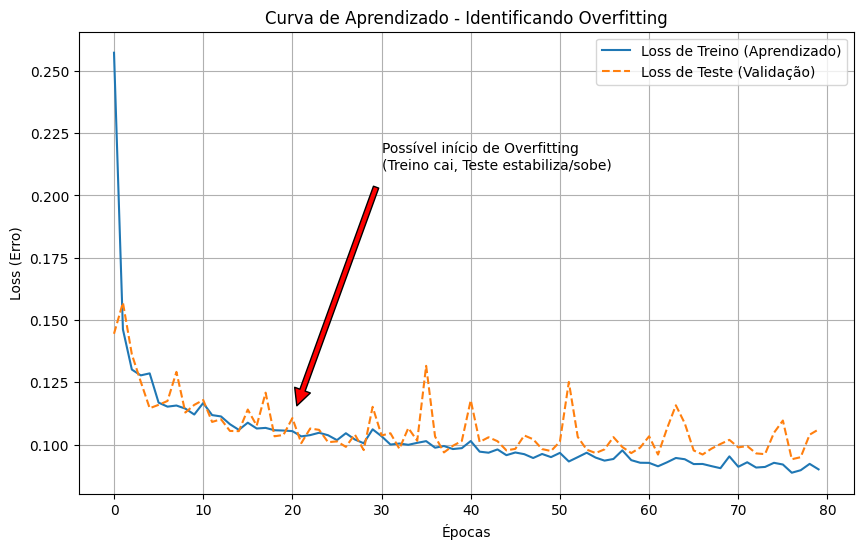

In [7]:
modelo_overfit = RedeNeuralBase(input_size, num_classes)
# Usando um otimizador forte com LR moderada e MUITAS épocas
optimizer_over = optim.Adam(modelo_overfit.parameters(), lr=0.01) 
criterion = nn.CrossEntropyLoss()

print("Treinando para verificar Overfitting...")
epochs_over = 80 # Número alto de épocas para forçar o distanciamento das curvas
loss_tr, loss_ts = treinar_modelo(modelo_overfit, criterion, optimizer_over, epochs_over, train_loader, test_loader)

# Plotando as curvas de aprendizado
plt.figure(figsize=(10, 6))
plt.plot(loss_tr, label='Loss de Treino (Aprendizado)')
plt.plot(loss_ts, label='Loss de Teste (Validação)', linestyle='--')
plt.title('Curva de Aprendizado - Identificando Overfitting')
plt.xlabel('Épocas')
plt.ylabel('Loss (Erro)')
plt.legend()
plt.grid(True)
plt.annotate('Possível início de Overfitting\n(Treino cai, Teste estabiliza/sobe)', 
             xy=(20, loss_ts[20]), xytext=(30, loss_ts[20]+0.1),
             arrowprops=dict(facecolor='red', shrink=0.05))
plt.show()

## Atividade D: Regularização e Otimização
Para combater o *Overfitting* visto acima, aplicaremos as técnicas ensinadas no Curso 2 do *deeplearning.ai*:
1. **Otimização Avançada (Adam):** Em vez do gradiente descendente estocástico (SGD) tradicional, usamos o Adam, que adapta a taxa de aprendizado para cada parâmetro (com *momentum*).
2. **Regularização L2 (Weight Decay):** Penaliza pesos muito grandes para impedir que o modelo confie demais em uma única *feature*.
3. **Dropout:** "Desliga" aleatoriamente neurônios durante o treinamento, forçando a rede a aprender caminhos redundantes e mais robustos.

--- Treinando Rede com Dropout, L2 e Adam ---
Época [1/80], Loss Treino: 0.6102, Loss Teste: 0.2868
Época [10/80], Loss Treino: 0.1416, Loss Teste: 0.1141
Época [20/80], Loss Treino: 0.1235, Loss Teste: 0.1043
Época [30/80], Loss Treino: 0.1182, Loss Teste: 0.1020
Época [40/80], Loss Treino: 0.1148, Loss Teste: 0.1007
Época [50/80], Loss Treino: 0.1138, Loss Teste: 0.0985
Época [60/80], Loss Treino: 0.1128, Loss Teste: 0.0987
Época [70/80], Loss Treino: 0.1140, Loss Teste: 0.1030
Época [80/80], Loss Treino: 0.1133, Loss Teste: 0.0988


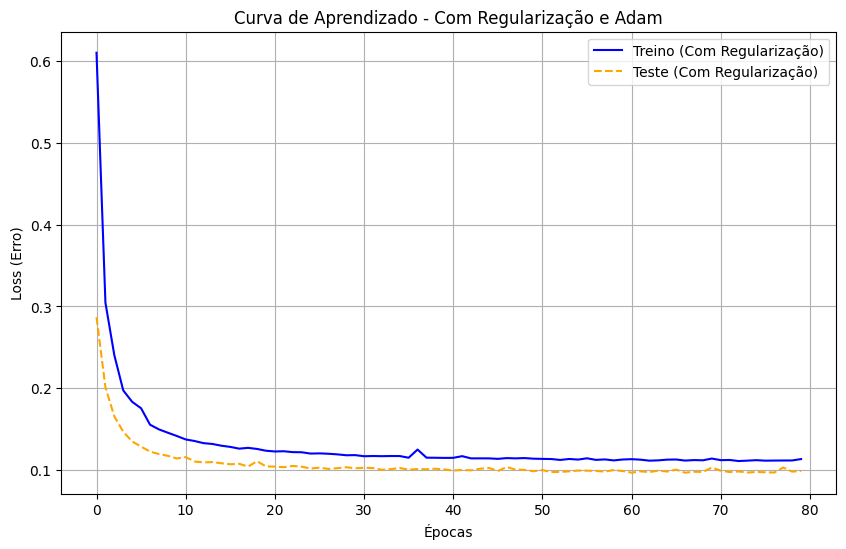


Conclusão: Com Regularização L2 e Dropout, a diferença entre a perda de treino e teste diminui consideravelmente, mostrando que o modelo está generalizando melhor para dados não vistos e combatendo o Overfitting de forma eficaz.


In [8]:
class RedeRegularizada(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RedeRegularizada, self).__init__()
        self.camada1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        # Dropout de 30%: a cada iteração, 30% dos neurônios são zerados
        self.dropout = nn.Dropout(p=0.3) 
        self.camada2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.saida = nn.Linear(32, num_classes)
        
    def forward(self, x):
        x = self.relu1(self.camada1(x))
        x = self.dropout(x) # Aplicando Dropout após a primeira camada
        x = self.relu2(self.camada2(x))
        x = self.dropout(x) # Aplicando Dropout após a segunda camada
        out = self.saida(x)
        return out

modelo_otimizado = RedeRegularizada(input_size, num_classes)

# Usando Adam (Otimizador avançado) e Weight Decay (Regularização L2)
optimizer_avancado = optim.Adam(modelo_otimizado.parameters(), lr=0.001, weight_decay=1e-4)

print("--- Treinando Rede com Dropout, L2 e Adam ---")
loss_tr_reg, loss_ts_reg = treinar_modelo(modelo_otimizado, criterion, optimizer_avancado, 80, train_loader, test_loader)

# Comparando os gráficos
plt.figure(figsize=(10, 6))
plt.plot(loss_tr_reg, label='Treino (Com Regularização)', color='blue')
plt.plot(loss_ts_reg, label='Teste (Com Regularização)', color='orange', linestyle='--')
plt.title('Curva de Aprendizado - Com Regularização e Adam')
plt.xlabel('Épocas')
plt.ylabel('Loss (Erro)')
plt.legend()
plt.grid(True)
plt.show()

print("\nConclusão: Com Regularização L2 e Dropout, a diferença entre a perda de treino e teste diminui consideravelmente, mostrando que o modelo está generalizando melhor para dados não vistos e combatendo o Overfitting de forma eficaz.")